In [78]:
import matplotlib.pyplot as plt
#import numpy as np
import pandas as pd
import math


names_bw=['time', 'bw', 'op1', 'write_size', 'op2' ]
names_latency=['time_msec', 'latency', 'op2', 'write_size', 'op3']

### Uniform Random on HM-LS

5.0
210.0
24.38MB/sec


<Figure size 640x480 with 0 Axes>

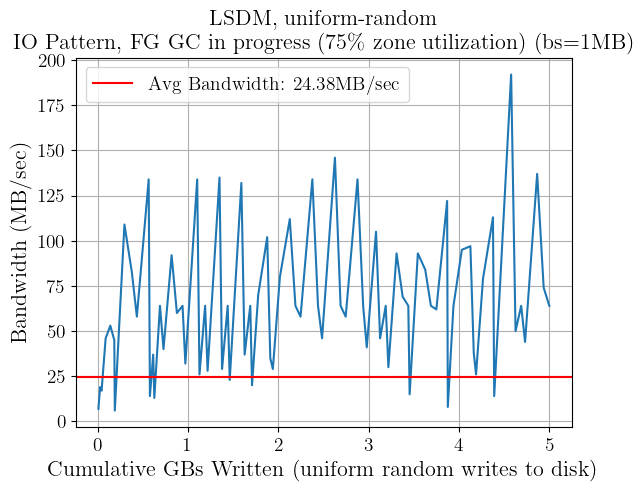

In [92]:
df_lat = pd.read_csv('/home/surbhi/measurements/worst_case/lsdm/75Util/1MB/8TB/uniform/lat_log_avg_lat.1.log', names=names_latency)
#process the latency data
data0 = df_lat.iloc[0]
df_lat['time_msec'] = df_lat['time_msec'] - data0.time_msec
df_lat['latency'] = df_lat['latency'] / (10 ** 6) # convert latency nsec to msec
# convert submission time to completion interval.
df_lat['ctime_msec'] = df_lat['time_msec'] + df_lat['latency']
df_lat['write_size'] = df_lat['write_size'].astype(int)
# Convert 'time_msec' to seconds
df_lat['time_seconds'] = df_lat['ctime_msec'] / 1000  # Convert milliseconds to seconds
# Round down the time_seconds to the nearest second
df_lat['time_seconds'] = df_lat['time_seconds'].astype(int)
df_binned = df_lat.groupby('time_seconds')['write_size'].sum().reset_index()
df_binned['cumulative_gb'] = df_binned['write_size'].cumsum() / (1024**3)
df_binned['cumulative_gb'] = df_binned['cumulative_gb'].astype(float)
df_binned.columns = ['time_seconds', 'bw', 'cumulative_gb']
df_binned['bw'] = df_binned['bw'] / (1024 ** 2) # Convert bytes to MB
data = df_binned.iloc[-1]
print(data.cumulative_gb)
print(data.time_seconds)
data0 = df_binned.iloc[0]
avg_bw = (data.cumulative_gb * 1024/data.time_seconds)
avg_bw_str = str(round(avg_bw,2)) + 'MB/sec'
print(avg_bw_str)
# Create a new dataframe with the count of writes per second
#new_df = df.groupby('time_seconds')['write_size'].sum().reset_index()
# Rename columns for clarity
#new_df.columns = ['time_seconds', 'total_writes']
#new_df['total_writes'] = new_df['total_writes'].cumsum() / 1024**3  # Convert bytes to MB
#print(new_df.shape)

#frames = [df_lat_time, df_write_time['write_size']]
#df_binned = pd.concat(frames, axis='columns')
# Display the new dataframe
#Create the line plots
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

fig, ax = plt.subplots()
ax.plot(df_binned['cumulative_gb'], df_binned['bw'], linestyle='-')

# Add labels and title
plt.xlabel('Cumulative GBs Written (uniform random writes to disk)', fontsize=16)
plt.xticks(fontsize=14)
plt.ylabel('Bandwidth (MB/sec)', fontsize=16)
plt.yticks(fontsize=14)

plt.axhline(y=avg_bw, color='r', linestyle='-', label='Avg Bandwidth: ' + avg_bw_str)
plt.title('LSDM, uniform-random\nIO Pattern, FG GC in progress (75\% zone utilization) (bs=1MB)', fontsize=16)
labels = plt.gca().get_xticklabels()
label_to_change = labels[-1].set_color('red')
plt.legend(loc='upper left', fontsize=14)

# Show the plot
plt.grid(True)  # Optionally, add grid lines
plt.savefig('/home/surbhi/github/surbhi-plots/LSDM/uniform-75Util-1MB.pdf', bbox_inches='tight')
plt.show()



5.0
203.0
25.22MB/sec


<Figure size 640x480 with 0 Axes>

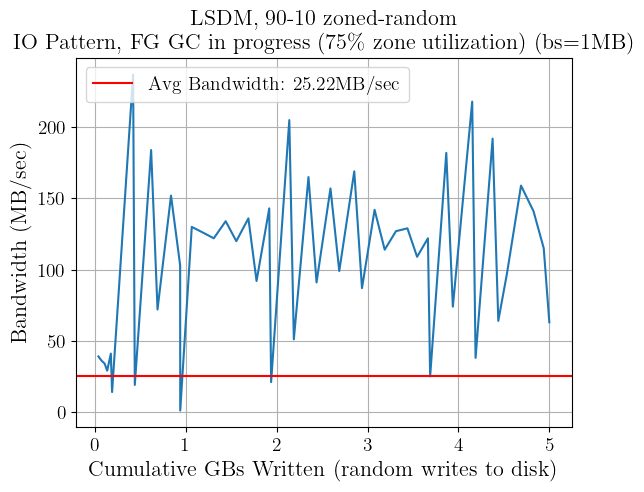

In [93]:
df = pd.read_csv('/home/surbhi/measurements/worst_case/lsdm/75Util/1MB/8TB/90-10-zoned/lat_log_avg_lat.1.log', names=names_latency)
#process the latency data
data0 = df_lat.iloc[0]
df_lat['time_msec'] = df_lat['time_msec'] - data0.time_msec
df_lat['latency'] = df_lat['latency'] / (10 ** 6) # convert latency nsec to msec
# convert submission time to completion interval.
df_lat['ctime_msec'] = df_lat['time_msec'] + df_lat['latency']
df_lat['write_size'] = df_lat['write_size'].astype(int)
# Convert 'time_msec' to seconds
df_lat['time_seconds'] = df_lat['ctime_msec'] / 1000  # Convert milliseconds to seconds
# Round down the time_seconds to the nearest second
df_lat['time_seconds'] = df_lat['time_seconds'].astype(int)
df_binned = df_lat.groupby('time_seconds')['write_size'].sum().reset_index()
df_binned['cumulative_gb'] = df_binned['write_size'].cumsum() / (1024**3)
df_binned['cumulative_gb'] = df_binned['cumulative_gb'].astype(float)
df_binned.columns = ['time_seconds', 'bw', 'cumulative_gb']
df_binned['bw'] = df_binned['bw'] / (1024 ** 2) # Convert bytes to MB
data = df_binned.iloc[-1]
print(data.cumulative_gb)
print(data.time_seconds)
data0 = df_binned.iloc[0]
avg_bw = (data.cumulative_gb * 1024/data.time_seconds)
avg_bw_str = str(round(avg_bw,2)) + 'MB/sec'
print(avg_bw_str)

# Display the new dataframe
#Create the line plots
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

fig, ax = plt.subplots()
ax.plot(df_binned['cumulative_gb'], df_binned['bw'], linestyle='-')

# Add labels and title
plt.xlabel('Cumulative GBs Written (random writes to disk)', fontsize=16)
plt.xticks(fontsize=14)
plt.ylabel('Bandwidth (MB/sec)', fontsize=16)
plt.yticks(fontsize=14)

plt.axhline(y=avg_bw, color='r', linestyle='-', label='Avg Bandwidth: ' + avg_bw_str)
plt.title('LSDM, 90-10 zoned-random\nIO Pattern, FG GC in progress (75\% zone utilization) (bs=1MB)', fontsize=16)
labels = plt.gca().get_xticklabels()
label_to_change = labels[-1].set_color('red')
plt.legend(loc='upper left', fontsize=14)

# Show the plot
plt.grid(True)  # Optionally, add grid lines
plt.savefig('/home/surbhi/github/surbhi-plots/LSDM/9010-zoned-75Util-1MB.pdf', bbox_inches='tight')
plt.show()



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<Figure size 640x480 with 0 Axes>

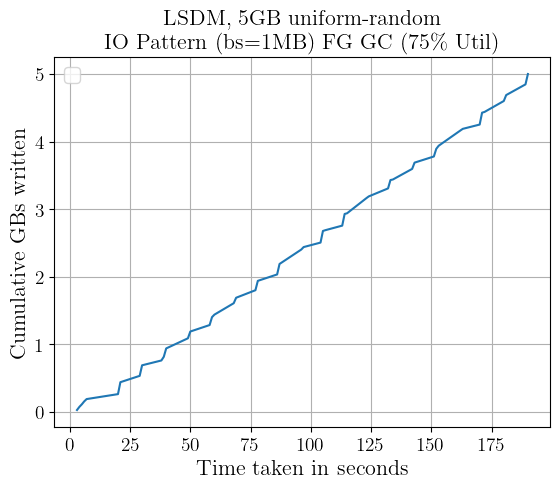

In [94]:
#Create the line plots
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42


fig, ax = plt.subplots()
ax.plot(new_df['time_seconds'], new_df['total_writes'], linestyle='-')

# Add labels and title
plt.xlabel('Time taken in seconds', fontsize=16)
plt.xticks(fontsize=14)
plt.ylabel('Cumulative GBs written', fontsize=16)
plt.yticks(fontsize=14)

plt.title('LSDM, 5GB uniform-random\nIO Pattern (bs=1MB) FG GC (75\% Util)', fontsize=16)
labels = plt.gca().get_xticklabels()
label_to_change = labels[-1].set_color('red')
plt.legend(loc='upper left', fontsize=14)

# Show the plot
plt.grid(True)  # Optionally, add grid lines
plt.savefig('/tmp/tmp.pdf', bbox_inches='tight')
plt.show()

In [95]:
df = pd.read_csv('/home/surbhi/measurements/worst_case/lsdm/75Util/1MB/8TB/90-10-LBA/lat_log_avg_lat.1.log', names=names_latency)
#process the bw data
# Convert 'time_msec' to seconds
df['time_seconds'] = df['time_msec']/1000

# Round down the time_seconds to the nearest second
df['time_seconds'] = df['time_seconds'].astype(int)

# Create a new dataframe with the count of writes per second
new_df = df.groupby('time_seconds')['write_size'].sum().reset_index()

# Rename columns for clarity
new_df.columns = ['time_seconds', 'total_writes']
new_df['total_writes'] = new_df['total_writes'].cumsum() / 1024**3  # Convert bytes to MB

# Display the new dataframe
print(new_df.shape)

(50, 2)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<Figure size 640x480 with 0 Axes>

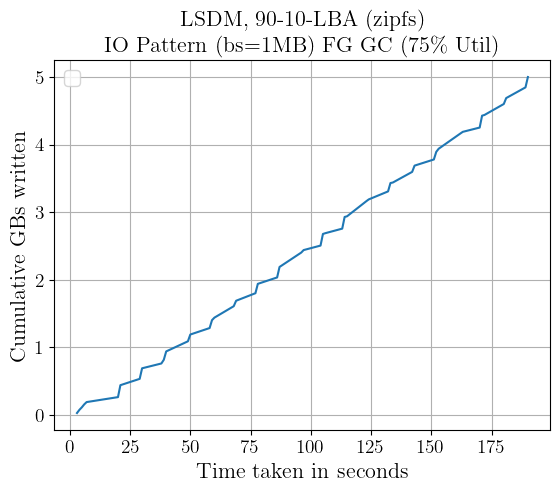

In [96]:
#Create the line plots
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42


fig, ax = plt.subplots()
ax.plot(new_df['time_seconds'], new_df['total_writes'], linestyle='-')

# Add labels and title
plt.xlabel('Time taken in seconds', fontsize=16)
plt.xticks(fontsize=14)
plt.ylabel('Cumulative GBs written', fontsize=16)
plt.yticks(fontsize=14)

plt.title('LSDM, 90-10-LBA (zipfs) \nIO Pattern (bs=1MB) FG GC (75\% Util)', fontsize=16)
labels = plt.gca().get_xticklabels()
label_to_change = labels[-1].set_color('red')
plt.legend(loc='upper left', fontsize=14)

# Show the plot
plt.grid(True)  # Optionally, add grid lines
plt.savefig('/tmp/tmp.pdf', bbox_inches='tight')
plt.show()